# Is visual data really richer than text?

This notebook goes with the post of the same name. It lets you run the experiment yourself.

**The claim.** People often say that a model that *sees* the world learns more than a model that *reads* about it.

**The test.** A ball flies through a small 32 × 32 world. One model gets pictures of the ball. A second model gets the
ball's position as two symbols. A third model gets the position as two numbers. The picture is drawn from the position
and from nothing else, so all three inputs carry the same information.

**What you can do here.**

1. Look at one flight in all three forms.
2. Train the three models in a short run (about 1 minute on a laptop).
3. Load the results of the full run (about 1 hour) and draw the figure from the post.
4. Run the control that shows where the picture advantage comes from.

The code is in `pixels_vs_tokens.py`. This notebook only calls it.

In [1]:
# Run this cell first. On Colab it gets the repository. On your own machine it does nothing.
import os, sys
if "google.colab" in sys.modules and not os.path.exists("pixels_vs_tokens.py"):
    !git clone -q https://github.com/vlrmzz/ai-claims-experiments
    %cd ai-claims-experiments/pixels-vs-tokens

In [2]:
import json, time

import numpy as np
import torch
import matplotlib.pyplot as plt

import pixels_vs_tokens as pvt

print("grid", pvt.GRID, "| frames seen", pvt.K_OBS, "| steps ahead to predict", pvt.HORIZON)

grid 32 | frames seen 4 | steps ahead to predict 4


## 1. One flight, three forms

The model sees the ball at 4 moments. It must predict where the ball is 4 steps after the last one.

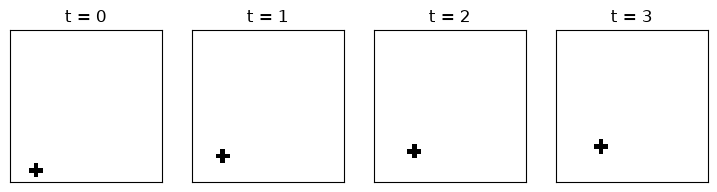

pixels : (4, 32, 32) numbers, each 0 or 1 (the pictures above)
tokens : [(5, 29), (6, 26), (8, 25), (9, 24)]  <- used as symbols: the model is not told that 12 is next to 13
numeric: [(-0.677, 0.871), (-0.613, 0.677), (-0.484, 0.613), (-0.419, 0.548)]  <- the same positions as numbers
target : (14, 29)


In [3]:
rng = np.random.default_rng(7)
cols, rows = pvt.sample_trajectories(1, rng)
K = pvt.K_OBS
frames = pvt.render(cols[:, :K], rows[:, :K])[0]

fig, axes = plt.subplots(1, K, figsize=(9, 2.5))
for j, ax in enumerate(axes):
    ax.imshow(1 - frames[j], cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(f"t = {j}")
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

positions = list(zip(cols[0, :K].tolist(), rows[0, :K].tolist()))
numeric = [tuple(round(v / (pvt.GRID - 1) * 2 - 1, 3) for v in p) for p in positions]
print("pixels :", frames.shape, "numbers, each 0 or 1 (the pictures above)")
print("tokens :", positions, " <- used as symbols: the model is not told that 12 is next to 13")
print("numeric:", numeric, " <- the same positions as numbers")
print("target :", (int(cols[0, -1]), int(rows[0, -1])))

## 2. Three models of the same size

If one model were larger, a better score could come from its size. So the three models have the same number of
parameters, to within 0.2 %.

In [4]:
for name, make in pvt.ARMS.items():
    print(f"{name:8s} {pvt.n_params(make()):,} parameters")

pixels   146,834 parameters
tokens   146,894 parameters
numeric  147,134 parameters


## 3. A short run

This trains each model once, on 1,000 flights, for 400 steps. The full run uses 2,500 steps, 6 training-set sizes
and 3 seeds. The order of the three models should match the full run.

The error is the distance in pixels between the predicted position and the true one. Lower is better.

In [5]:
STEPS, N_TRAIN = 400, 1000
LR = {"pixels": 3e-3, "tokens": 1e-3, "numeric": 1e-3}     # the learning rates that the full run selected

val = pvt.make_dataset(1000, seed=10_001)
test = pvt.make_dataset(2000, seed=10_002)
train = pvt.make_dataset(N_TRAIN, seed=1)

quick = {}
for name, make in pvt.ARMS.items():
    t0 = time.time()
    _, quick[name] = pvt.train_once(make, train, val, test, LR[name], STEPS, pvt.BATCH, seed=0)
    print(f"{name:8s} test error {quick[name]:5.2f} px   ({time.time() - t0:.0f} s)")

print(f"\nfor comparison, a curve fitted through the 4 points and extended: {pvt.naive_extrapolation(n=2000):.2f} px")

pixels   test error  2.26 px   (23 s)


tokens   test error  2.76 px   (1 s)


numeric  test error  2.02 px   (1 s)

for comparison, a curve fitted through the 4 points and extended: 6.00 px


## 4. The full run

`results.json` holds every run of the full experiment. `results_control.json` holds the control from section 5.
The table shows the mean test error and its spread over 3 seeds, for each training-set size `n`.

In [6]:
import os
import viz
from IPython.display import Image

results = viz.merge_control(json.load(open("results.json")))
viz.summary(results)


     n |          numeric |           pixels |      pixels_flat |           tokens
----------------------------------------------------------------
   125 |      2.25 ± 0.12 |      3.27 ± 0.20 |      4.19 ± 0.11 |      4.74 ± 0.12
   250 |      2.10 ± 0.01 |      2.98 ± 0.03 |      3.46 ± 0.15 |      3.60 ± 0.11
   500 |      2.06 ± 0.01 |      2.48 ± 0.06 |      3.07 ± 0.16 |      3.10 ± 0.10
  1000 |      2.02 ± 0.01 |      2.35 ± 0.05 |      2.71 ± 0.06 |      2.78 ± 0.09
  2000 |      2.00 ± 0.00 |      2.23 ± 0.03 |      2.41 ± 0.03 |      2.54 ± 0.00
  4000 |      1.99 ± 0.01 |      2.14 ± 0.01 |      2.25 ± 0.02 |      2.33 ± 0.02
tokens_4x: 2.356 px
numeric_4x: 1.998 px

naive quadratic extrapolation: 6.031 px
median seconds per run, numeric: 7.8
median seconds per run, pixels: 194.6
median seconds per run, pixels_flat: 12.6
median seconds per run, tokens: 7.4


wrote _out/fig-sample-efficiency.png


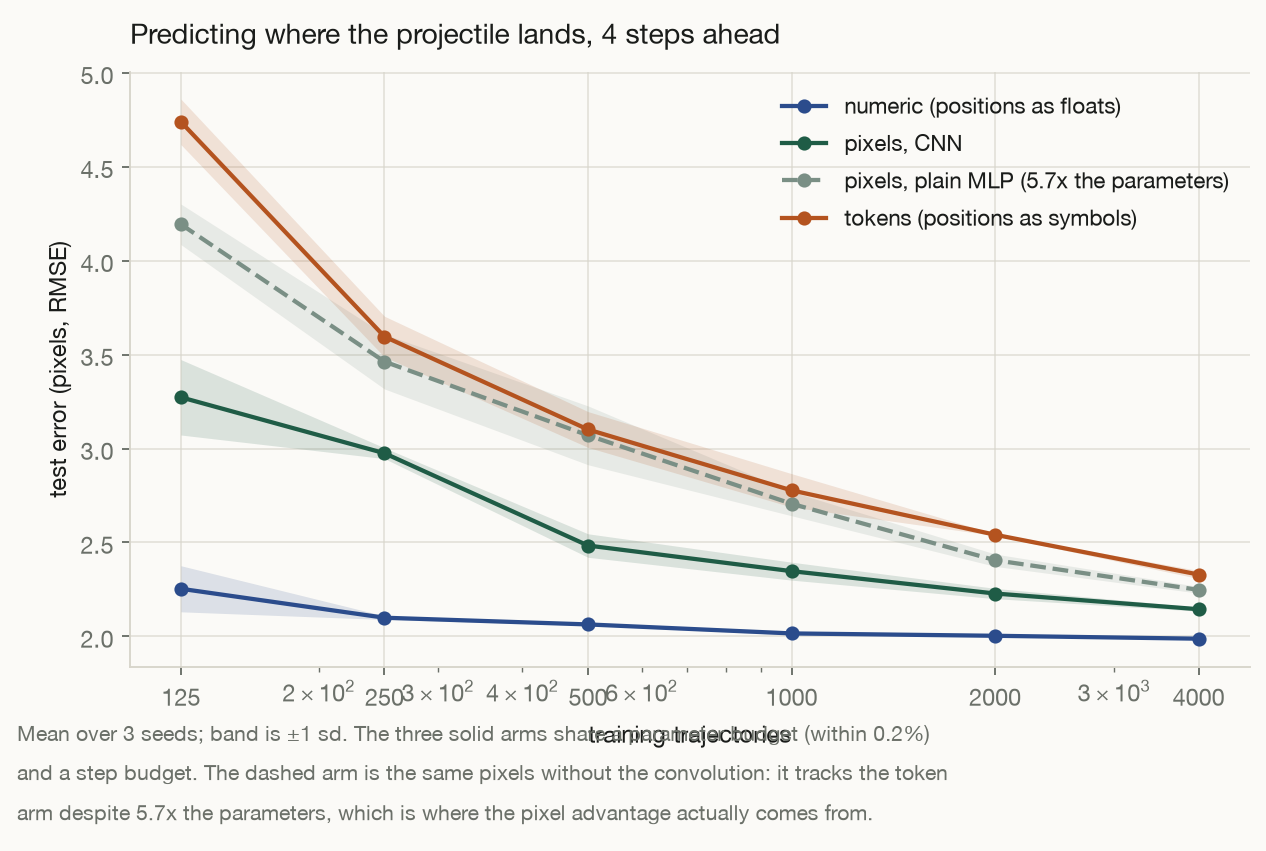

In [7]:
os.makedirs("_out", exist_ok=True)
viz.fig_curves(results, path="_out/fig-sample-efficiency.png")
Image("_out/fig-sample-efficiency.png", width=760)

## 5. The control: where does the picture advantage come from?

The picture model is a convolutional network. A convolution assumes that nearby pixels belong together. The symbol
model has no such help.

So the control gives the **same pictures** to a plain network with no convolution (`pixels_flat` in the table above).
That network has 5.7 times the parameters of the others. If pictures were richer in themselves, it would still do well.

Compare the `pixels_flat` column with the `pixels` and `tokens` columns in the table. The cell below repeats the
short run from section 3 for this model.

In [8]:
from control_flat_pixels import FlatPixelNet

print(f"pixels_flat {pvt.n_params(FlatPixelNet()):,} parameters")
lr_flat = json.load(open("results_control.json"))["lr"]
t0 = time.time()
_, quick["pixels_flat"] = pvt.train_once(FlatPixelNet, train, val, test, lr_flat, STEPS, pvt.BATCH, seed=0)
print(f"pixels_flat test error {quick['pixels_flat']:5.2f} px   ({time.time() - t0:.0f} s)")

print("\nshort run, all four:")
for name, err in sorted(quick.items(), key=lambda kv: kv[1]):
    print(f"  {name:12s} {err:5.2f} px")

pixels_flat 841,678 parameters


pixels_flat test error  2.65 px   (2 s)

short run, all four:
  numeric       2.02 px
  pixels        2.26 px
  pixels_flat   2.65 px
  tokens        2.76 px


## 6. Change something

- `STEPS` and `N_TRAIN` in section 3: more steps and more flights bring the short run closer to the full run.
- `pvt.HORIZON`: how far ahead the model must predict. Set it before you make the datasets.
- `pvt.RADIUS`: the size of the ball in the pictures.

To repeat the full run from a terminal (about 1 hour on a laptop):

```
python pixels_vs_tokens.py run
python control_flat_pixels.py
python viz.py
```